In [58]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.spatial.distance import squareform  
import tifffile
from skimage.measure import regionprops_table
import random
from matplotlib.colors import BoundaryNorm

import matplotlib.pyplot as plt
from itertools import combinations
import networkx as nx
import igraph as ig
import leidenalg
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.spatial import cKDTree
from sklearn.metrics import adjusted_rand_score, silhouette_score, adjusted_mutual_info_score
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
from sklearn.metrics import adjusted_mutual_info_score
from matplotlib.colors import to_rgba
from matplotlib.lines import Line2D

# ---- Global variables ----
endo_genes = ["CDH5", "PECAM1", "VWF", "KDR", "FLT1", "PDGFB"]
fibro_genes = ["PDGFRB", "COL1A1", "COL1A2"]
GENES = ['CDH5', 'MMP1', 'COL1A1', 'KDR', 'VWF', 'PECAM1', 'VEGFA', 'DLL4', 'ITGA6', 'SEMA3F', 'JAG1', 'FLT1', 'PDGFB', 'COL1A2', 'APLN', 'PDGFRB', 'ANGPT2', 'ICAM1']

XY_UM = 0.1893014                    # micron per pixel in x/y
Z_UM = 0.7996567                     # micron per pixel in z
IMAGE_KEY = "source_folder"          # one physical image per source_folder
output_dir = Path(".")

MAX_CLUSTERS = 8                     # largest K the Bernoulli BIC search may pick per lineage
SPATIAL_RADIUS_UM = 30.0             # two cells are "neighbours" if within this distance (same image)
N_PERM = 200                         # permutations for the spatial neighbour-enrichment null

# ---- Data (binary gene matrix + physical coordinates) ----
all_data = pd.read_csv("clean_data_with_assigned_cell_type.csv")
# Rebuild the on/off string in GENES order (CSV loads it as an int, dropping leading zeros!!).
all_data["binary_state"] = all_data[GENES].astype(int).astype(str).agg("".join, axis=1)
X = all_data[list(GENES)].astype(int).to_numpy()


## 2. Which gene states define distinct cell states?

Three complementary views of the same 18-gene 0/1 matrix, asking whether the population
is a few clean types or a **continuum**:

- **Bernoulli mixture** - what recurring probabilistic states exist? BIC picks the number
  of states K.
- **Responsibilities** - how discrete are individual cell assignments? For each cell the
  posterior over states tells us whether it belongs cleanly to one state (discrete) or is
  smeared across several (continuum).
- **Logistic PCA / latent factors** - can those ~K states be explained by a *smaller*
  number of continuous biological axes? If 1-2 latent axes reconstruct most of the
  binary structure, the "states" are really positions along a continuum.

The emphasis is on **endothelial** cells, which we suspect form 2+ overlapping programmes
rather than discrete types.

### What we're trying to find out

Each cell is described by which of the 18 genes it has switched on or off. The big
question: do cells fall into a handful of **clean, distinct types**, or do they blur into
one another along a **continuous gradient**? We look at endothelial and fibroblast cells
separately (the lineages behave very differently), and for the per-lineage runs we
**exclude that lineage's defining markers** (`CDH5`/`VWF`/`PECAM1` for endothelial,
`COL1A1`/`COL1A2` for fibroblast) so the clusters reflect *functional* variation rather
than just re-discovering the markers. Three methods, so the answer doesn't hinge on one.

**1. Grouping cells into recurring patterns (Bernoulli mixture).** Discover a few typical
on/off "signatures" and sort each cell towards the one it resembles; BIC picks how many
signatures are worth having.
- *Assumes* genes switch on independently within a state and a `0` means truly "off".
- *Drawback:* forces hard-ish groups onto data that may be continuous.

**2. How confidently was each cell sorted? (responsibilities).** The mixture also reports
how sure it was per cell ("95% group A" vs "50/50 A/B"). Lots of borderline cells = the
groups are convenient labels on a smooth gradient (a **continuum**).
- *Best single check* for the discrete-vs-continuum question.

**3. Can a few "dials" explain everything? (logistic PCA).** Fits continuous latent axes to
the 0/1 data. If 1-2 axes rebuild most of the pattern, the states are just positions on a
gradient; if it needs many axes, structure is genuinely multi-faceted.
- *Drawback:* axes are statistical, not guaranteed to be single biological programmes.

### What we found (this run)

| Population | cells | # states (K) | % cells sorted confidently (>=0.8) | logistic-PCA (2 axes / 6 axes) | verdict |
|---|---|---|---|---|---|
| all cells | 9,472 | 7 | ~55% | 38% / 85% | continuum-leaning |
| endothelial (markers excluded) | 7,388 | **4** | **38%** | 46% / 93% | **continuum** |
| fibroblast (markers excluded) | 732 | **2** | **99%** | 70% / 99% | **discrete** |

### How to read this + do the methods agree?

**Yes - all three methods agree, per lineage.**
- **Fibroblasts are discrete.** Only 2 states, *almost every* cell sorted with high
  confidence (99% >=0.8), and logistic PCA saturates fast (70% of the pattern in 2 axes).
  Different starting points converge on the same answer: a few clean states.
- **Endothelial cells are a continuum.** Even with only 4 states, just ~38% of cells are
  confidently assigned - most sit *between* states - and logistic PCA keeps climbing with
  no early plateau (needs ~6 axes). All three signals point the same way: endothelial cells
  are **not discrete types** but a smooth spread, built on a shared `CDH5` backbone, whose
  strongest axis is `KDR`/`VEGFA` **angiogenic** activation, with a smaller `DLL4`/`FLT1`
  tip/sprouting flavour.

**Interpretation in words:** treat the endothelial "clusters" as *waypoints along a
gradient of angiogenic activation*, not as separate cell types; treat the fibroblast
clusters as genuine states. The spatial test below then asks whether these gradient
waypoints occupy real tissue territory (they do for the angiogenic states).

In [ ]:
# Shared helpers + a readable cluster summariser used by every approach in section 2.

def binary_state_to_code(binary_state):
    """'100100...' -> '1_4' (1-indexed positions of the ON genes; '0' if none on)."""
    genes_on = [str(position + 1) for position, bit in enumerate(binary_state) if bit == "1"]
    return "_".join(genes_on) if genes_on else "0"


def state_code_to_gene_names(state_code, genes):
    """'1_4_7' -> 'CDH5, KDR, VWF' using the 1-indexed gene order ('0' -> 'none')."""
    if state_code == "0":
        return "none"
    return ", ".join(genes[int(position) - 1] for position in state_code.split("_"))


def describe_clusters(cells, cell_labels, genes, method_name, cell_type, top_states=3):
    """Print a plain-English summary of one method's clusters for one cell type.

    For every cluster it lists the gene states that dominate it, e.g.
    "cluster 1 (120 cells, 34%): likely states include 60% 1_4 (CDH5, KDR); ...".
    Cells with label -1 (unassigned) are ignored. Returns the same information as a
    tidy DataFrame so it can be collected and saved.
    """
    labels = pd.Series(cell_labels, index=cells.index)
    assigned = labels[labels >= 0]
    cluster_sizes = assigned.value_counts()
    n_cells = len(assigned)
    summary_rows = []
    for cluster_id in cluster_sizes.index:
        member_index = assigned[assigned == cluster_id].index
        n = len(member_index)
        state_counts = cells.loc[member_index, "binary_state"].value_counts()
        described = [
            f"{100 * count / n:.0f}% {binary_state_to_code(state)} "
            f"({state_code_to_gene_names(binary_state_to_code(state), genes)})"
            for state, count in state_counts.head(top_states).items()
        ]
        main_states = "; ".join(described)
        summary_rows.append({
            "cell_type": cell_type,
            "method": method_name,
            "cluster": cluster_id,
            "n_cells": n,
            "pct_of_cell_type": 100 * n / n_cells,
            "main_states": main_states,
        })
    # print()
    return pd.DataFrame(summary_rows)

In [36]:
#  Approach 2: Bernoulli mixture (probabilistic) 

def fit_bernoulli_mixture_once(gene_matrix, n_states, max_iter=300, tol=1e-6, rng=None):
    """One EM run of a Bernoulli mixture.

    Returns (weights, on_probabilities, log_likelihood, responsibilities).
    """
    rng = rng if rng is not None else np.random.default_rng(0)
    n_cells, n_genes = gene_matrix.shape
    on_probabilities = rng.uniform(0.1, 0.9, size=(n_states, n_genes))
    weights = np.full(n_states, 1.0 / n_states)
    log_likelihood_prev = -np.inf
    responsibilities = np.full((n_cells, n_states), 1.0 / n_states)
    for _ in range(max_iter):
        log_prob = (gene_matrix @ np.log(on_probabilities.T)
                    + (1 - gene_matrix) @ np.log(1 - on_probabilities.T)) + np.log(weights)
        row_max = log_prob.max(axis=1, keepdims=True)
        log_norm = row_max.ravel() + np.log(np.exp(log_prob - row_max).sum(axis=1))
        log_likelihood = log_norm.sum()
        responsibilities = np.exp(log_prob - log_norm[:, None])
        cells_per_state = responsibilities.sum(axis=0) + 1e-9
        weights = cells_per_state / n_cells
        on_probabilities = np.clip((responsibilities.T @ gene_matrix) / cells_per_state[:, None],
                                   1e-3, 1 - 1e-3)
        if abs(log_likelihood - log_likelihood_prev) < tol * (abs(log_likelihood_prev) + 1e-9):
            break
        log_likelihood_prev = log_likelihood
    return weights, on_probabilities, log_likelihood, responsibilities

def fit_bernoulli_mixture(gene_matrix, n_states, n_restarts=8, seed=0):
    """Sort cells into `n_states` hidden states using a Bernoulli mixture.

    The idea: imagine a few hidden cell states. Each state has, for every gene, a
    chance that the gene is switched on, and each cell is a slightly noisy copy of one
    state. Fitting the model tells us those states and which one each cell most likely
    belongs to. Because it is a probability model of how the on/off patterns arise, it
    is a good sanity check on the distance-based clustering. It assumes genes turn on
    independently within a state and that a 0 really means "off" (not just missed).

    Runs the fit several times from random starts and keeps the best. Returns a dict
    with the state weights, per-gene on-probabilities, one hard label per cell, the
    full soft responsibilities (cells x states), and the BIC score (lower = better fit
    once the number of states is penalised).
    """
    gene_matrix = np.asarray(gene_matrix, dtype=float)
    rng = np.random.default_rng(seed)
    best_fit = None
    for _ in range(n_restarts):
        candidate = fit_bernoulli_mixture_once(gene_matrix, n_states, rng=rng)
        if best_fit is None or candidate[2] > best_fit[2]:
            best_fit = candidate
    weights, on_probabilities, log_likelihood, responsibilities = best_fit
    labels = responsibilities.argmax(axis=1)
    n_cells, n_genes = gene_matrix.shape
    n_params = n_states * n_genes + (n_states - 1)
    bic = -2 * log_likelihood + n_params * np.log(n_cells)
    return {
        "n_states": n_states,
        "weights": weights,
        "on_probabilities": on_probabilities,
        "labels": labels,
        "responsibilities": responsibilities,
        "bic": bic,
    }


def select_bernoulli_mixture(gene_matrix, candidate_states=range(2, 11), seed=0):
    """Fit the mixture for several numbers of states and keep the lowest-BIC one.

    Returns (best_fit, fits_by_number_of_states).
    """
    fits_by_number_of_states = {
        n_states: fit_bernoulli_mixture(gene_matrix, n_states, seed=seed)
        for n_states in candidate_states
    }
    best_n_states = min(fits_by_number_of_states, key=lambda k: fits_by_number_of_states[k]["bic"])
    return fits_by_number_of_states[best_n_states], fits_by_number_of_states

In [37]:
#  Approach 3: Logistic PCA (continuous latent axes for binary data)
#
# Are the ~K Bernoulli states really a handful of discrete types, or positions along a
# few CONTINUOUS axes? Ordinary PCA assumes Gaussian data; here each gene is 0/1, so we
# use logistic PCA: model P(gene on) = sigmoid(mu_j + scores . loadings_j), i.e. the
# log-odds (natural parameters) are low-rank. Fitted with the majorization-minimization
# (MM) scheme of de Leeuw / Landgraf & Lee - at each step the logistic loss is bounded
# by a quadratic whose minimiser is a plain SVD of a "working response", so it reduces
# to repeated PCA and converges monotonically.

def _sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -30, 30)))


def binary_deviance(binary_matrix, natural_params):
    """-2 * Bernoulli log-likelihood of `binary_matrix` given log-odds `natural_params`."""
    p = np.clip(_sigmoid(natural_params), 1e-9, 1 - 1e-9)
    return -2.0 * np.sum(binary_matrix * np.log(p) + (1 - binary_matrix) * np.log(1 - p))


def fit_logistic_pca(binary_matrix, n_components, max_iter=200, tol=1e-6):
    """Logistic PCA of a binary (cells x genes) matrix via MM / iterated SVD.

    Models the log-odds as  Theta = mu + scores @ loadings.T  (rank n_components).
    Returns a dict with:
      mu         : per-gene intercept (log-odds of the marginal ON-rate),
      scores     : cells x n_components latent coordinates (the continuous axes),
      loadings   : genes x n_components gene weights on each axis,
      deviance   : -2 log-likelihood of the fitted rank-k model (lower = better).
    """
    X = np.asarray(binary_matrix, dtype=float)
    n_cells, n_genes = X.shape
    p0 = np.clip(X.mean(axis=0), 1e-3, 1 - 1e-3)
    mu = np.log(p0 / (1 - p0))
    theta = np.tile(mu, (n_cells, 1))
    scores = np.zeros((n_cells, n_components))
    loadings = np.zeros((n_genes, n_components))
    deviance_prev = np.inf
    for _ in range(max_iter):
        # MM working response: quadratic surrogate to the logistic loss (Hessian <= 1/4).
        working = theta + 4.0 * (X - _sigmoid(theta))
        mu = working.mean(axis=0)
        centred = working - mu
        U, S, Vt = np.linalg.svd(centred, full_matrices=False)
        k = min(n_components, len(S))
        scores = U[:, :k] * S[:k]
        loadings = Vt[:k].T
        theta = mu + scores @ loadings.T
        deviance = binary_deviance(X, theta)
        if abs(deviance_prev - deviance) < tol * (abs(deviance_prev) + 1e-9):
            break
        deviance_prev = deviance
    return {"mu": mu, "scores": scores, "loadings": loadings, "deviance": deviance}

In [ ]:
def cluster_and_report(cells, label, max_clusters=8, k_min=2, store_to_df=False,
                       lpca_max_components=6, exclude_genes=None):
    """Bernoulli mixture + responsibility-based discreteness + logistic PCA on one subset.
    Returns a dict (label, cells, K, genes, bmm_labels, responsibilities, max_resp,
    resp_entropy, lpca_by_k, dev_explained, lpca_scores, summaries) or None if <10 cells
    carry reads.
    """
    cells = cells[cells["has_reads"]]
    if len(cells) < 10:
        print(f"{label}: only {len(cells)} cells with reads - skipping\n")
        return None
    exclude_genes = list(exclude_genes or [])
    genes_used = [g for g in GENES if g not in set(exclude_genes)]
    matrix = cells[genes_used].astype(int).to_numpy()
    print(f"POPULATION: {label}  ({len(cells):,} cells with reads)")
    if exclude_genes:
        print(f"Marker genes excluded from clustering (still define lineage): "
              f"{', '.join(exclude_genes)}")

    # --- 1. Bernoulli mixture - BIC picks K ---
    best_mixture, mixtures_by_k = select_bernoulli_mixture(
        matrix, candidate_states=range(k_min, max_clusters + 1))
    K = best_mixture["n_states"]
    bmm_labels = best_mixture["labels"]
    responsibilities = best_mixture["responsibilities"]
    summary = describe_clusters(cells, bmm_labels, GENES, "Bernoulli", label)

    # --- 2. Responsibilities - how discrete are the assignments? ---
    max_resp = responsibilities.max(axis=1)
    resp_entropy = -(responsibilities * np.log(responsibilities + 1e-12)).sum(axis=1) / np.log(K)
    pct_confident = 100 * np.mean(max_resp >= 0.8)

    # --- 3. Logistic PCA - can a few continuous axes explain the states? ---
    p0 = np.clip(matrix.mean(axis=0), 1e-9, 1 - 1e-9)
    theta_null = np.tile(np.log(p0 / (1 - p0)), (len(matrix), 1))
    dev_null = binary_deviance(matrix, theta_null)     # intercept-only baseline
    n_comp_max = int(min(lpca_max_components, matrix.shape[1] - 1))
    lpca_by_k = {k: fit_logistic_pca(matrix, k) for k in range(1, n_comp_max + 1)}
    dev_explained = {k: 1 - lpca_by_k[k]["deviance"] / dev_null for k in lpca_by_k}
    lpca_scores = lpca_by_k[min(2, n_comp_max)]["scores"]   # 2-axis embedding for the map

    # --- Figure 1: model selection + the Bernoulli states themselves ---
    candidate_ks = list(mixtures_by_k)
    bic_values = [mixtures_by_k[k]["bic"] for k in candidate_ks]
    state_probabilities = pd.DataFrame(
        best_mixture["on_probabilities"], columns=genes_used,
        index=[f"state {k} ({weight:.0%})" for k, weight in enumerate(best_mixture["weights"])])
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={"width_ratios": [1, 2]})
    axes[0].plot(candidate_ks, bic_values, "o-")
    axes[0].axvline(K, color="red", ls="--", label=f"best K = {K}")
    axes[0].set(xlabel="K (number of states)", ylabel="BIC",
                title=f"{label}: mixture model selection")
    axes[0].legend()
    sns.heatmap(state_probabilities, cmap="viridis", vmin=0, vmax=1, ax=axes[1],
                cbar_kws={"label": "P(gene on | state)"})
    axes[1].set_title(f"{label}: Bernoulli mixture states (K={K})")
    plt.tight_layout(); plt.show()

    # --- Figure 2: continuum diagnostics (responsibilities + logistic PCA) ---
    fig, axes = plt.subplots(1, 3, figsize=(21, 5))
    axes[0].hist(max_resp, bins=30, range=(1.0 / K, 1.0), color="steelblue")
    axes[0].axvline(0.8, color="red", ls="--", label="0.8")
    axes[0].set(xlabel="max responsibility per cell", ylabel="cells",
                title=f"{label}: assignment confidence\n"
                      f"({pct_confident:.0f}% of cells >=0.8. Low % suggests continuum of states rather than discrete)")
    axes[0].legend()

    ks = list(dev_explained)
    axes[1].plot(ks, [100 * dev_explained[k] for k in ks], "o-")
    axes[1].set(xlabel="number of logistic-PCA axes", ylabel="% binary deviance explained",
                ylim=(0, 100),
                title=f"{label}: logistic PCA\n(sharp early plateau means few continuous axes)")
    axes[1].grid(alpha=0.3)

    # Discrete colour per state so the colourbar ticks line up with the state ids.
    state_cmap = plt.get_cmap("tab10", K)
    state_norm = BoundaryNorm(np.arange(-0.5, K + 0.5, 1.0), K)
    scatter = axes[2].scatter(lpca_scores[:, 0], lpca_scores[:, 1], c=bmm_labels,
                              cmap=state_cmap, norm=state_norm, s=8, alpha=0.6)
    axes[2].set(xlabel="logistic PCA axis 1", ylabel="logistic PCA axis 2",
                title=f"{label}: cells on the latent axes\n(coloured by Bernoulli state)")
    plt.colorbar(scatter, ax=axes[2], label="Bernoulli state", ticks=range(K))
    plt.tight_layout(); plt.show()

    if store_to_df:
        bmm_offset = int(all_data["bmm"].max()) + 1
        all_data.loc[cells.index, "bmm"] = bmm_labels + bmm_offset
        all_data.loc[cells.index, "bmm_confidence"] = max_resp
        all_data.loc[cells.index, "lpca1"] = lpca_scores[:, 0]
        all_data.loc[cells.index, "lpca2"] = lpca_scores[:, 1]

    return {
        "label": label, "cells": cells, "K": K, "genes": genes_used,
        "bmm_labels": bmm_labels, "responsibilities": responsibilities,
        "max_resp": max_resp, "resp_entropy": resp_entropy,
        "lpca_by_k": lpca_by_k, "dev_explained": dev_explained, "lpca_scores": lpca_scores,
        "summaries": summary,
    }

In [39]:
# ---- Spatial-analysis helpers (used by the "are the clusters real in space?" run below) ----

def cluster_top_genes(sub, lineage, clustered, genes_by_lineage, n_top=2, min_on=0.2):
    """Name a cluster by its most UPREGULATED non-excluded genes (ON-fraction vs the lineage
    baseline). Excluded marker genes (CDH5/VWF/PECAM1, COL1A1/COL1A2) never appear here."""
    genes_here = genes_by_lineage.get(lineage, GENES)
    cluster_on = sub[genes_here].mean()
    baseline_on = clustered.loc[clustered["cell_type"] == lineage, genes_here].mean()
    enrichment = (cluster_on / (baseline_on + 1e-9))[cluster_on >= min_on].sort_values(ascending=False)
    if enrichment.empty:                       # backbone cluster with nothing extra switched on
        enrichment = cluster_on.sort_values(ascending=False)
    return ", ".join(enrichment.head(n_top).index)


def neighbour_enrichment(cells, order, title, ax, radius=SPATIAL_RADIUS_UM, n_perm=N_PERM, seed=0):
    """Within-image neighbour-enrichment permutation test + heatmap.
    Diagonal z > 0 -> a group's cells sit next to each other more than chance; off-diagonal
    z > 0 -> two groups are neighbours more than chance."""
    cells = cells[cells["group"].isin(order)].reset_index(drop=True)
    pos = {g: i for i, g in enumerate(order)}
    code = cells["group"].map(pos).to_numpy()
    image_positions = [g.index.to_numpy() for _, g in cells.groupby(IMAGE_KEY)]
    edges = []
    for pidx in image_positions:
        coords = cells.loc[pidx, ["x_um", "y_um", "z_um"]].to_numpy()
        tree = cKDTree(coords)
        for a, b in tree.query_pairs(radius):
            edges.append((pidx[a], pidx[b]))
    E = np.array(edges)
    n = len(order)

    def _counts(lbl):
        m = np.zeros((n, n))
        if len(E):
            for u, v in zip(lbl[E[:, 0]], lbl[E[:, 1]]):
                m[u, v] += 1
                m[v, u] += 1
        return m

    def _shuffle(lbl, generator):
        out = lbl.copy()
        for pidx in image_positions:
            out[pidx] = generator.permutation(lbl[pidx])
        return out

    obs = _counts(code)
    generator = np.random.default_rng(seed)
    perm = np.stack([_counts(_shuffle(code, generator)) for _ in range(n_perm)])
    zmat = (obs - perm.mean(0)) / (perm.std(0) + 1e-9)
    zdf = pd.DataFrame(zmat, index=order, columns=order)
    sns.heatmap(zdf, cmap="coolwarm", center=0, annot=True, fmt=".1f", square=True,
                ax=ax, cbar_kws={"label": "neighbour-enrichment z-score"})
    ax.set_title(title)
    return zdf


POPULATION: all cells (with reads)  (9,472 cells with reads)
Bernoulli BIC picked K = 7 states.



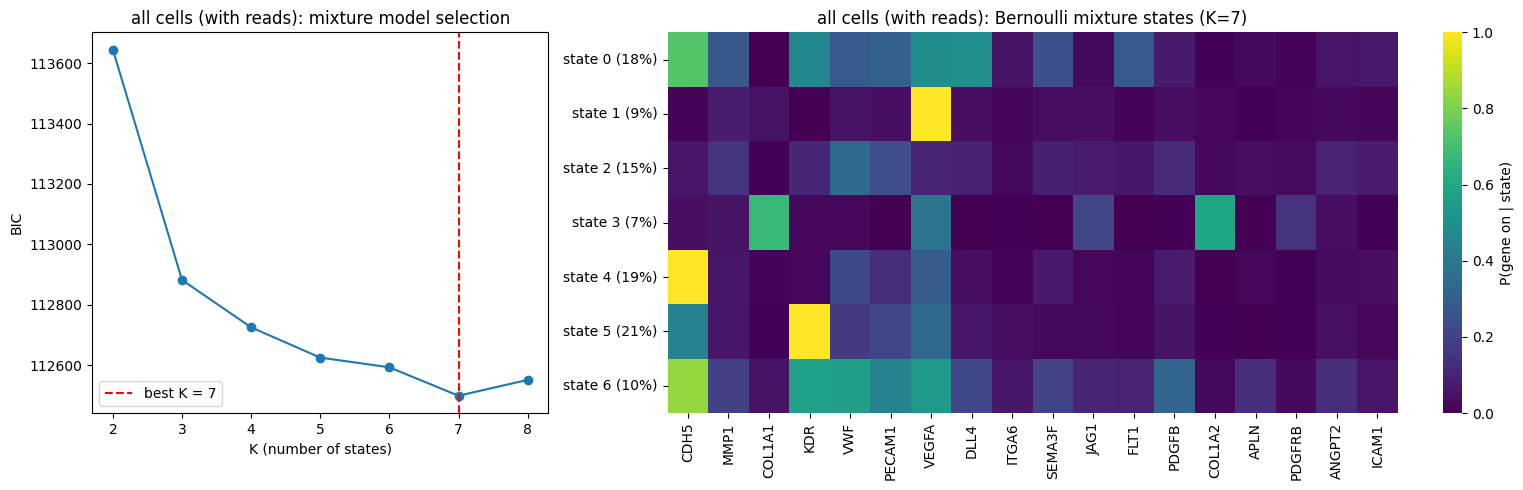

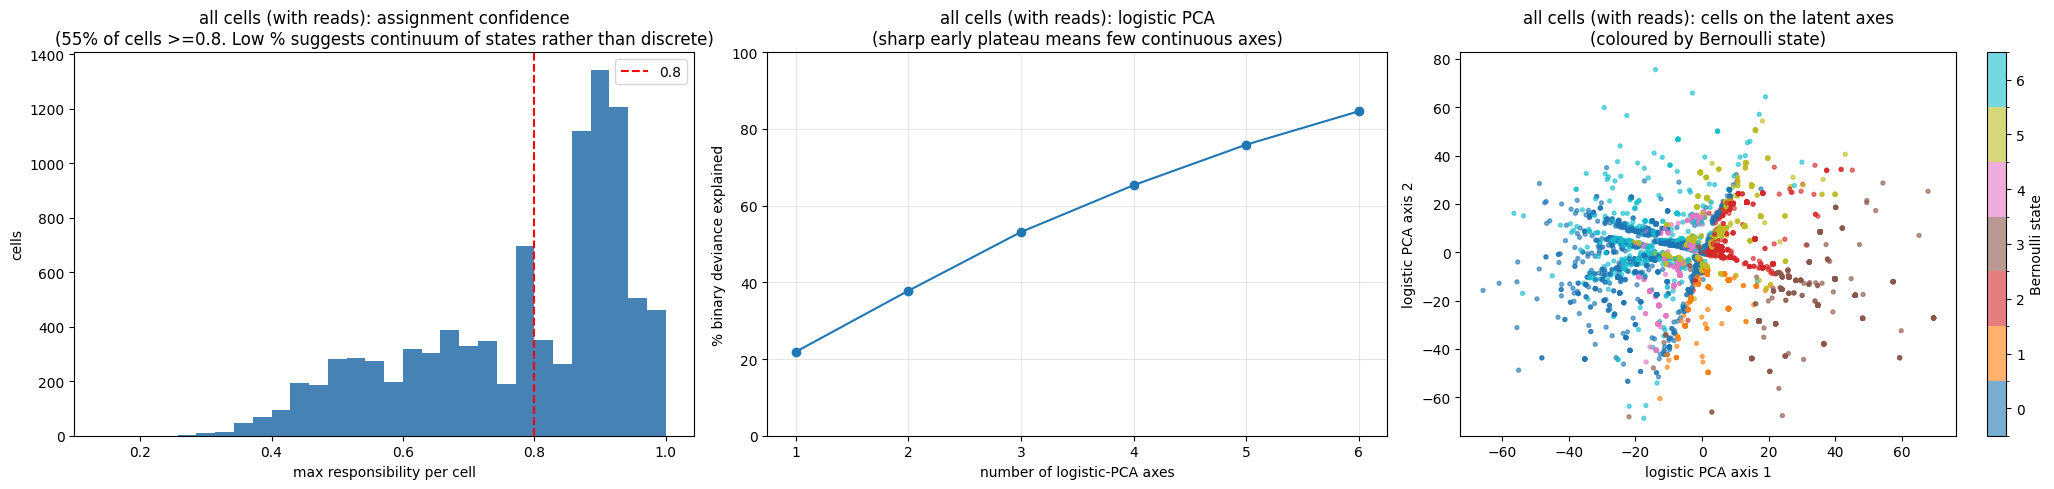

In [40]:
# ============================================================================
# RUN SECTION 2 - Bernoulli mixture + logistic PCA on three population scopes:
#   (a) ALL cells with reads (zero-count cells excluded),
#   (b) Endothelial - confident or tentative (Unknown and Zero Reads excluded),
#   (c) Fibroblast  - confident or tentative (Unknown and Zero Reads excluded).
# ============================================================================
# Section 3 reads these per-cell columns; the per-lineage runs below fill them
# (bmm offset so the two lineages keep distinct ids). Reset them first.
all_data["bmm"] = -1
all_data["bmm_confidence"] = np.nan
all_data["lpca1"] = np.nan
all_data["lpca2"] = np.nan

# (a) ALL cells with reads - both lineages + unknown together.
# Overlaps the per-lineage runs, so its labels are NOT stored back to all_data.
res_pop = cluster_and_report(all_data, "all cells (with reads)", max_clusters=MAX_CLUSTERS)

POPULATION: endothelial  (7,325 cells with reads)
Marker genes excluded from clustering (still define lineage): CDH5, VWF, PECAM1
Bernoulli BIC picked K = 4 states.



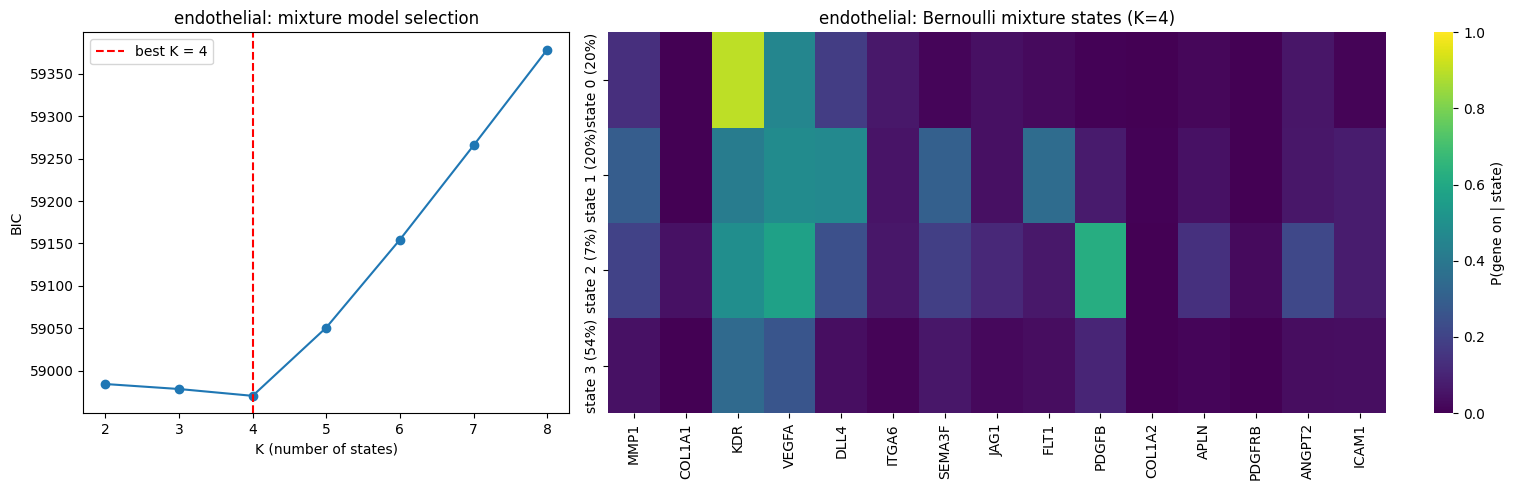

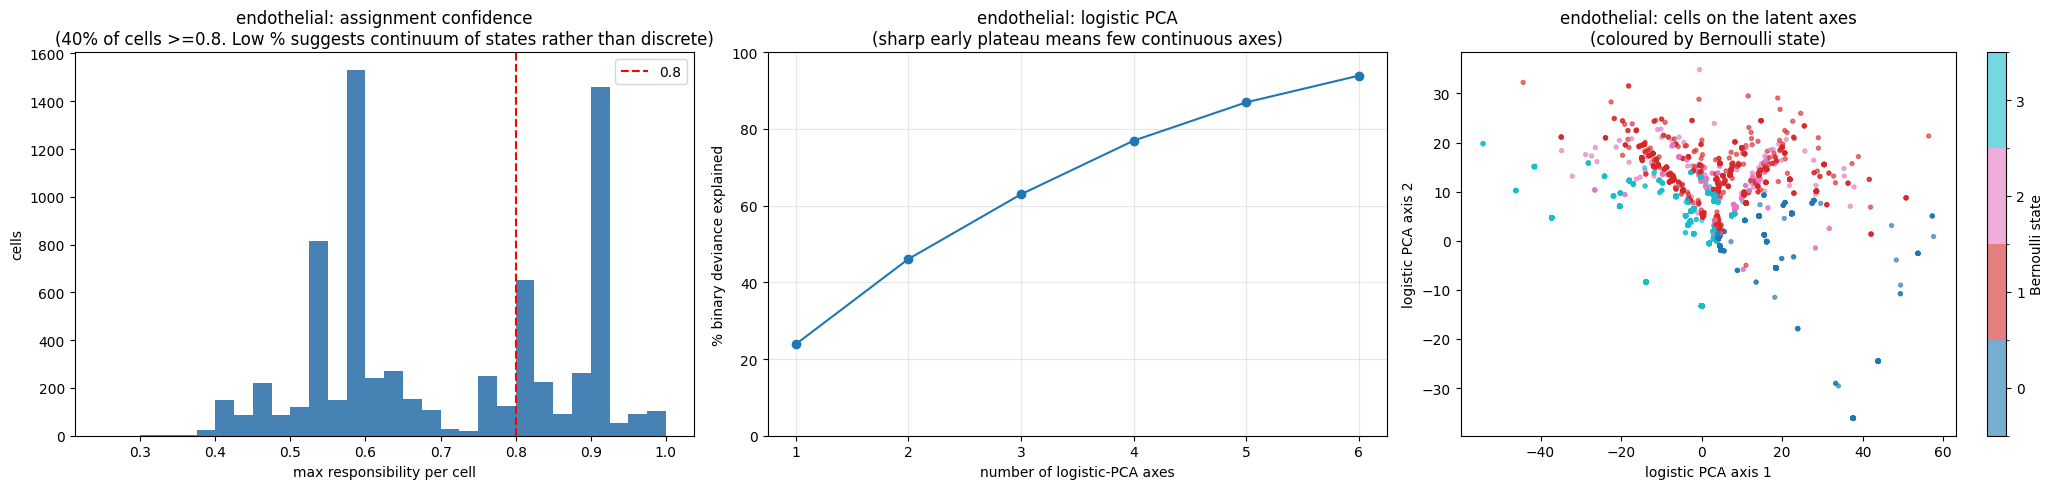

In [ ]:
# (b) ENDOTHELIAL - confident or tentative endothelial cells (Unknown and Zero Reads
# excluded by the cell_type filter). Stored back to all_data for the spatial analysis.
# CDH5/VWF/PECAM1 define the lineage upstream, so exclude them from the clustering.
res_endo_all = cluster_and_report(
    all_data[all_data.cell_type == "Endothelial"], "endothelial",
    max_clusters=MAX_CLUSTERS, store_to_df=True, exclude_genes=["CDH5", "VWF", "PECAM1"])
# Name the endothelial logistic-PCA axes: which genes pull each end apart.
# Turns "axis 1 / axis 2" on the right-hand scatter into biology (e.g. angiogenic vs core).
endo_loadings = pd.DataFrame(
    res_endo_all["lpca_by_k"][2]["loadings"], index=res_endo_all["genes"], columns=["axis 1", "axis 2"])
for axis in ["axis 1", "axis 2"]:
    ranked = endo_loadings[axis].sort_values()
    pos_end = ", ".join(ranked.tail(4).index[::-1])   # genes at the + end
    neg_end = ", ".join(ranked.head(4).index)         # genes at the - end
    print(f"{axis}:  + end = {pos_end}   <-->   - end = {neg_end}")
# display(endo_loadings.round(2).sort_values("axis 1"))

POPULATION: fibroblast  (834 cells with reads)
Marker genes excluded from clustering (still define lineage): COL1A1, COL1A2
Bernoulli BIC picked K = 2 states.



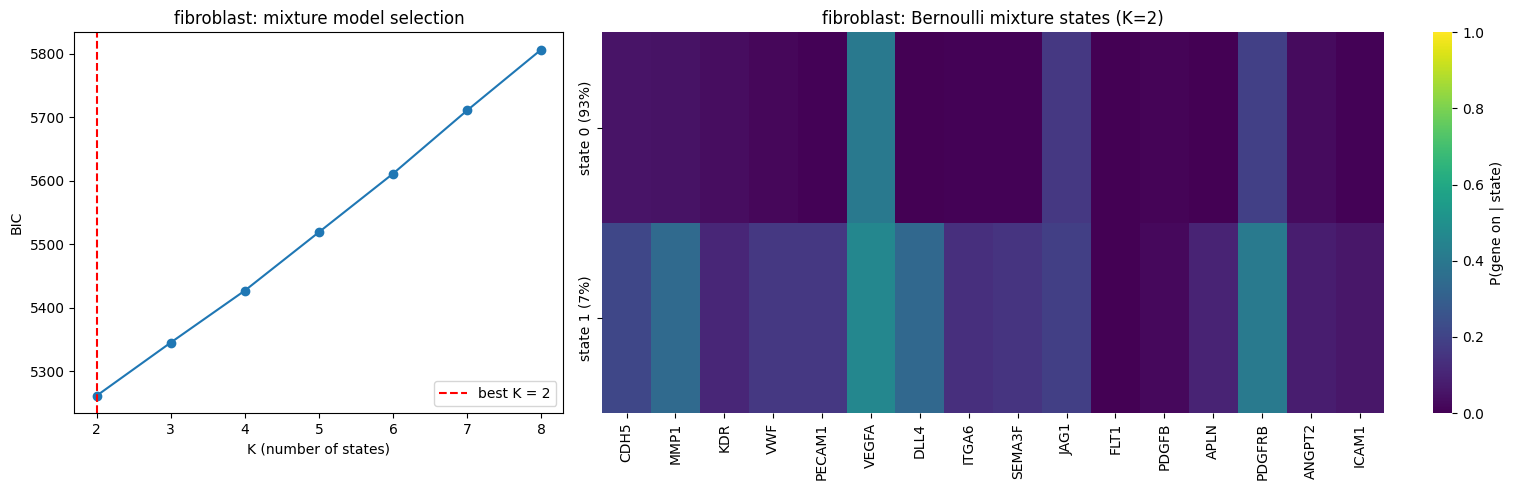

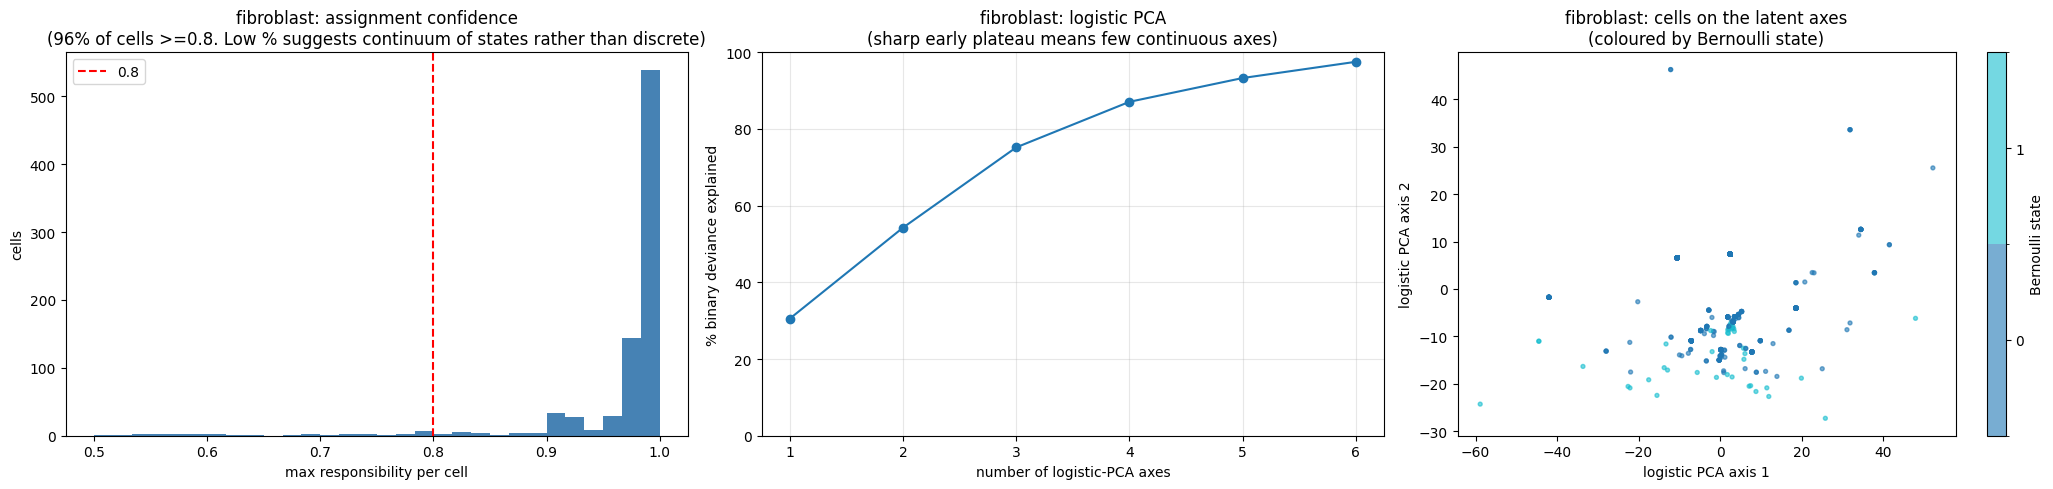

In [43]:
# (c) FIBROBLAST - confident or tentative fibroblast cells (Unknown and Zero Reads
# excluded by the cell_type filter). Stored back to all_data for the spatial analysis.
# COL1A1/COL1A2 define the lineage upstream, so exclude them from the clustering.
res_fibro_all = cluster_and_report(
    all_data[all_data.cell_type == "Fibroblast"], "fibroblast",
    max_clusters=MAX_CLUSTERS, store_to_df=True, exclude_genes=["COL1A1", "COL1A2"])

In [44]:
# Collect every run's cluster summary into one tidy table.
all_runs = [res_pop, res_endo_all, res_fibro_all]
cluster_overview = pd.concat([r["summaries"] for r in all_runs if r is not None],
                             ignore_index=True)
cluster_overview.to_csv(output_dir / "section2_cluster_overview.csv", index=False)
print("Saved -> section2_cluster_overview.csv")


Saved -> section2_cluster_overview.csv


### Are the gene-state clusters "real" in tissue?

The clusters above were found from gene expression alone, ignoring where the cells sit.
If a cluster is a genuine biological state (not just a statistical slice of a continuum),
its cells should tend to **occupy the same tissue territory** rather than being scattered
at random. We test this directly in space using the per-cell cluster labels stored in
`all_data["bmm"]`.

For each pair of clusters we count how often their cells are spatial neighbours (within
30 um, in the same image), then compare to a **shuffled null** where cluster labels are
randomly permuted within each image. The result is a z-score matrix:

- **Diagonal z > 0** - a cluster's own cells sit next to each other more than chance, i.e.
  the cluster forms real spatial patches (evidence it is a genuine state).
- **Off-diagonal z > 0** - two different clusters are neighbours more than chance (e.g.
  endothelial cluster 2 tends to sit beside fibroblast cluster 1), revealing which states
  organise together in tissue.

The map on the right shows one image coloured by cluster so the patches can be eyeballed.

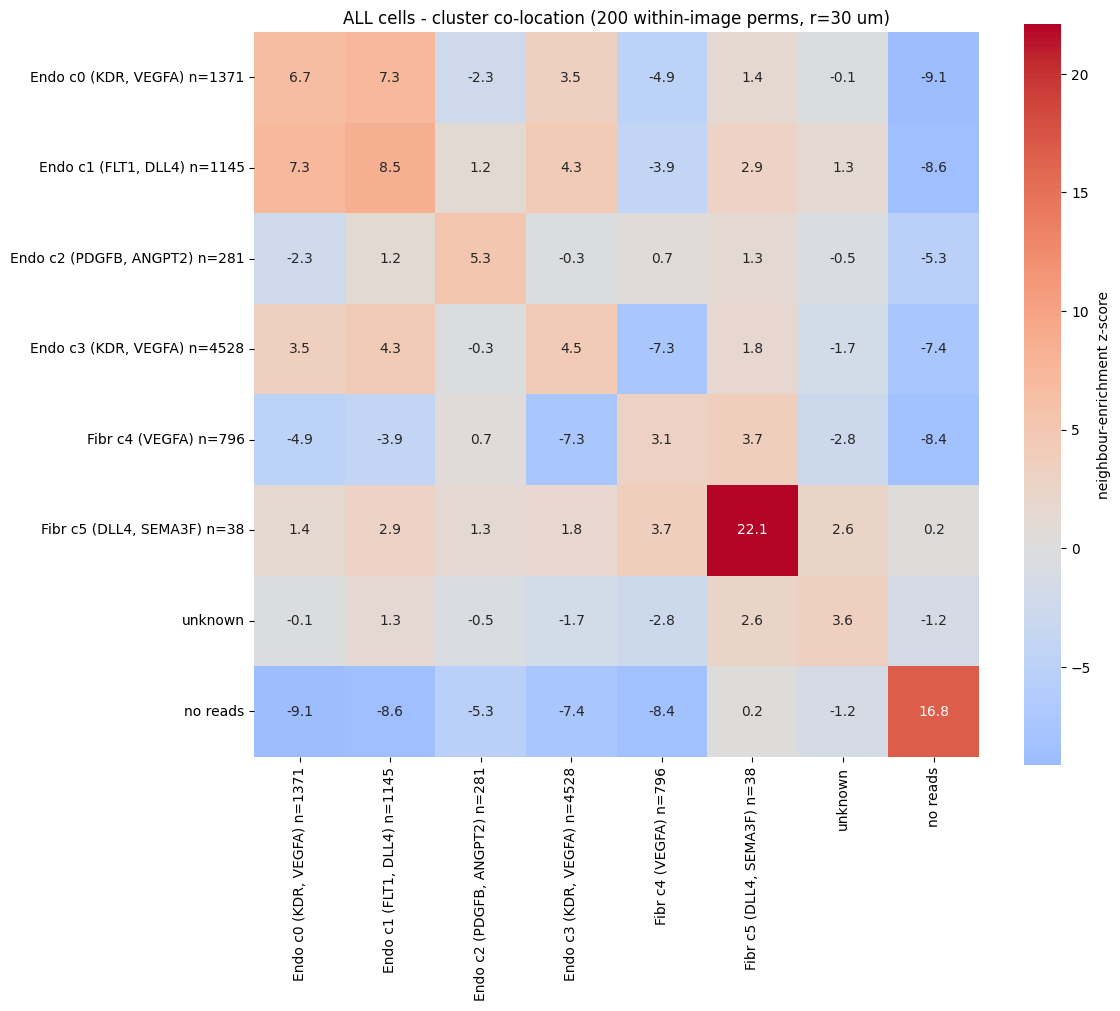

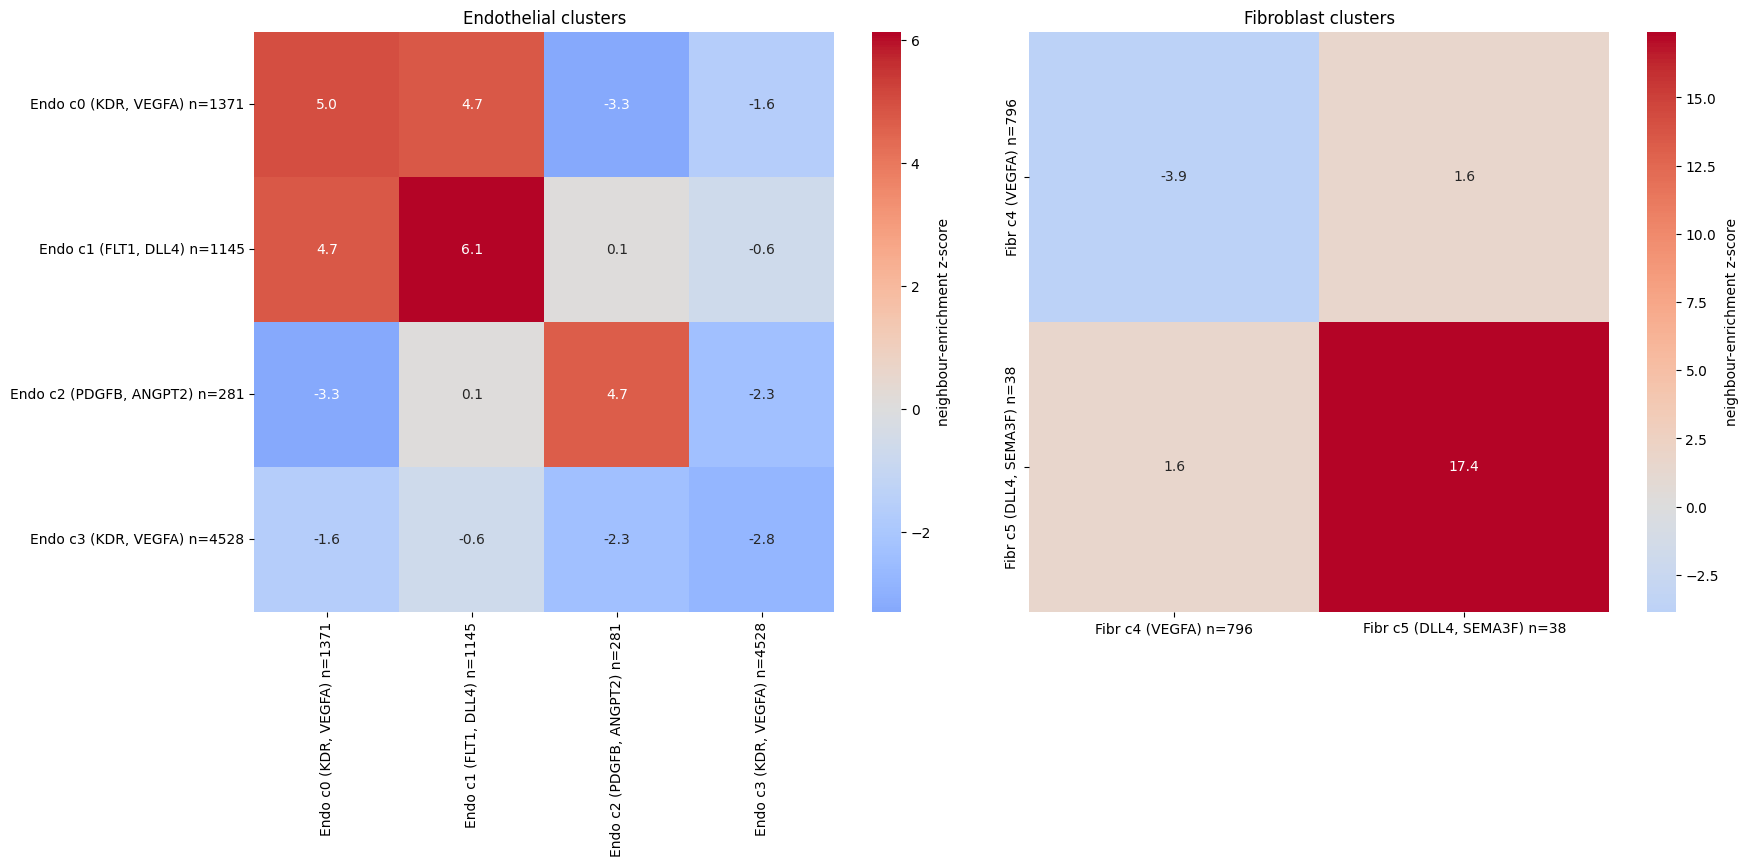

In [47]:
clustered = all_data[all_data["bmm"] >= 0].reset_index(drop=True)
cluster_ids = np.sort(clustered["bmm"].unique())

# Genes actually used for each lineage's clustering (the marker genes were excluded upstream).
genes_by_lineage = {}
for r in (res_endo_all, res_fibro_all):
    if r is not None:
        genes_by_lineage[r["cells"]["cell_type"].mode().iat[0]] = r["genes"]

# Name each cluster by its most upregulated non-excluded genes.
cluster_lineage, cluster_name_of = {}, {}
for c in cluster_ids:
    sub = clustered[clustered["bmm"] == c]
    lin = sub["cell_type"].mode().iat[0]
    cluster_lineage[c] = lin
    cluster_name_of[c] = f"{lin[:4]} c{c} ({cluster_top_genes(sub, lin, clustered, genes_by_lineage)}) n={len(sub)}"
cluster_names = [cluster_name_of[c] for c in cluster_ids]
endo_names = [cluster_name_of[c] for c in cluster_ids if cluster_lineage[c] == "Endothelial"]
fibro_names = [cluster_name_of[c] for c in cluster_ids if cluster_lineage[c] == "Fibroblast"]

# Per-cell display group: cluster name, else "unknown" lineage or "no reads" (all-0 cell).
group = all_data["bmm"].map(cluster_name_of)
group = group.where(all_data["bmm"] >= 0, np.where(all_data["has_reads"], "unknown", "no reads"))
df_disp = all_data.assign(group=group)

# (1) ALL cells together (clusters + unknown + all-0 "no reads").
all_order = cluster_names + ["unknown", "no reads"]
fig, ax = plt.subplots(figsize=(1.1 * len(all_order) + 3, 1.0 * len(all_order) + 2))
z_all = neighbour_enrichment(df_disp, all_order,
                             f"ALL cells - cluster co-location ({N_PERM} within-image perms, "
                             f"r={SPATIAL_RADIUS_UM:.0f} um)", ax)
plt.tight_layout(); plt.show()

# (2) Endothelial-only and (3) fibroblast-only (clusters within each lineage).
fig, axes = plt.subplots(1, 2, figsize=(9 * 2, 8))
neighbour_enrichment(df_disp[df_disp["cell_type"] == "Endothelial"], endo_names,
                     "Endothelial clusters", axes[0])
neighbour_enrichment(df_disp[df_disp["cell_type"] == "Fibroblast"], fibro_names,
                     "Fibroblast clusters", axes[1])
plt.tight_layout(); plt.show()


# QC: WHy do No Reads Cluster?
A- they're more likely at high z

'no reads' cells: 3,575 of 13,047 (27.4%)

Median per group (no reads vs has reads):
          edge_dist_um  z_frac
no_reads                      
False           119.95    0.50
True            109.23    0.57 



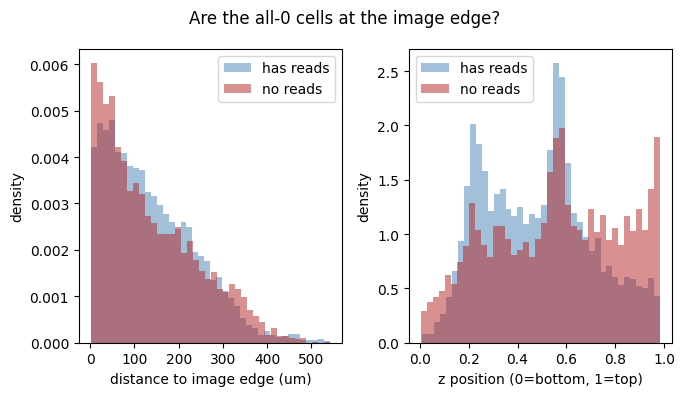

In [59]:
# Compare the all-0 cells to the rest of hte pop to see if they're more likely in
# certain positiosn (edge/top)
# if 0-reads are spatially confined - likely technical artefact, if their distribution
# strongly overlaps with the other cells, it points more to a genuine popultation that's 
# intermixed with the others
# We compare all-0 cells
# to cells-with-reads on these three axes. If no-reads cells pile up at edges / z-extremes
# / high density, the strong no-reads<->no-reads spatial co-location is most likely a
# technical failure; if their distributions overlap the with-reads cells, it points more
# to a genuine population negative for all 18 panel genes.
qc = all_data.copy()
qc["no_reads"] = ~qc["has_reads"]

# Distance to the nearest XY image edge (um) from the physical coords already in the table.
# Left UNCLIPPED so out-of-bounds centroids surface as negative distances (see the flag below).
x_extent_um = qc["Xmax"] * XY_UM
y_extent_um = qc["Ymax"] * XY_UM
qc["edge_dist_um"] = np.minimum.reduce([
    qc["x_um"], x_extent_um - qc["x_um"],
    qc["y_um"], y_extent_um - qc["y_um"]])
qc["z_frac"] = qc["z_um"] / (qc["Zmax"] * Z_UM)

# Flag cells whose centroid sits OUTSIDE the stored image extent (negative edge distance).
outside = qc["edge_dist_um"] < 0
n_out = int(outside.sum())
if n_out:
    print(f"WARNING: {n_out} cells ({100 * outside.mean():.2f}%) have a NEGATIVE edge distance "
          f"(centroid outside the stored Xmax/Ymax extent):")

metrics = ["edge_dist_um", "z_frac",]
print(f"'no reads' cells: {qc['no_reads'].sum():,} of {len(qc):,} ({100 * qc['no_reads'].mean():.1f}%)\n")
print("Median per group (no reads vs has reads):")
print(qc.groupby("no_reads")[metrics].median().round(2), "\n")

fig, ax = plt.subplots(ncols = 2, figsize=(7, 4))
labels = {"edge_dist_um": "distance to image edge (um)", "z_frac": "z position (0=bottom, 1=top)",
          "local_density": "neighbours within 30 um"}
for a, col in zip(ax, metrics):
    for flag, colour in [(False, "steelblue"), (True, "firebrick")]:
        a.hist(qc.loc[qc.no_reads == flag, col], bins=40, density=True, alpha=0.5,
               color=colour, label="no reads" if flag else "has reads")
    a.set_xlabel(labels[col]); a.set_ylabel("density"); a.legend()
fig.suptitle("Are the all-0 cells at the image edge?")
plt.tight_layout(); plt.show()

### Are the "no reads" cells technical? (QC result)

**27.4%** of segmented cells detect zero of the 18 panel genes, and earlier we saw these
all-0 cells co-locate strongly with each other. The QC above asks whether that is a
**technical dropout** signature on three axes:

- **Crowding / over-segmentation - ruled out.** No-reads and has-reads cells have an
  *identical* local density (median 3 neighbours within 30 um, fully overlapping histograms).
  So the all-0 cells are **not** just over-segmented fragments in dense regions.
- **Image edge - minor.** No-reads cells sit slightly closer to the field edge (median 108 vs
  119 um) but the distributions overlap almost entirely - a weak effect at most.
- **Z-plane - the one real technical signal.** No-reads cells are **enriched toward the top of
  the stack** (median z-fraction 0.57 vs 0.50, with a clear excess in the top planes). This is
  the classic depth-dependent hybridisation/imaging drop-off, where upper (or optically worse)
  planes lose signal.

**Interpretation.** The strong no-reads<->no-reads co-location is **at least partly technical**
- driven by a z-depth dropout gradient, not by crowding. But the large overlap with has-reads
cells on every axis means it is **not fully explained** by these artefacts, so a subset may be
genuinely panel-negative cells. Either way, the all-0 cells should **not** be read as a real
biological "programme"; they are correctly kept flagged and excluded from the gene-state and
module analyses.

### Conclusions - gene states & their spatial reality

**Approach.** Bernoulli mixture (recurring states) + responsibilities (how discrete each
assignment is) + logistic PCA (can a few continuous axes explain it?), then a within-image
label-shuffling permutation test asking whether each state's cells sit together in tissue.

**Assumptions / drawbacks.** All-0-read cells were split into lineages artificially and
carry no state (flagged, never clustered). The permutation z-scores need enough cells per
image; tiny clusters (e.g. the n=12 fibroblast state with a huge z) are unreliable. "State"
is a soft label on what is, for endothelial cells, largely a continuum.

**Biology.**
- **Endothelial = a structured continuum**, not discrete types (Bernoulli, responsibilities
  and logistic PCA all agree). The main axis is `KDR`/`VEGFA` angiogenic activation on a
  `CDH5` backbone, with a `DLL4`/`FLT1`/`MMP1` tip/sprouting flavour.
- **Fibroblasts = a few genuinely discrete states** (high confidence, fast PCA plateau).
- **Are the states "real" in space?** The angiogenic endothelial states form genuine
  spatial patches (diagonal z ~ 6-9) - distinct tissue territory. The plain `CDH5`-only
  backbone is spatially diffuse (low z), as expected for a shared baseline. Collagen
  fibroblasts sit *apart* from the angiogenic endothelium (negative off-diagonal), not
  intermixed.

**Do the methods agree?** Yes - the three discrete-vs-continuum diagnostics agree per
lineage, and the independent spatial test confirms that the *functional* endothelial states
(not the backbone) are spatially organised.